In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline           
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score




In [50]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
test_ids = test['Id']

In [51]:
cat_cols = train.select_dtypes(include = object).columns.tolist()
num_cols = train.select_dtypes(include = np.number).columns.tolist()

In [52]:
cat_cols

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

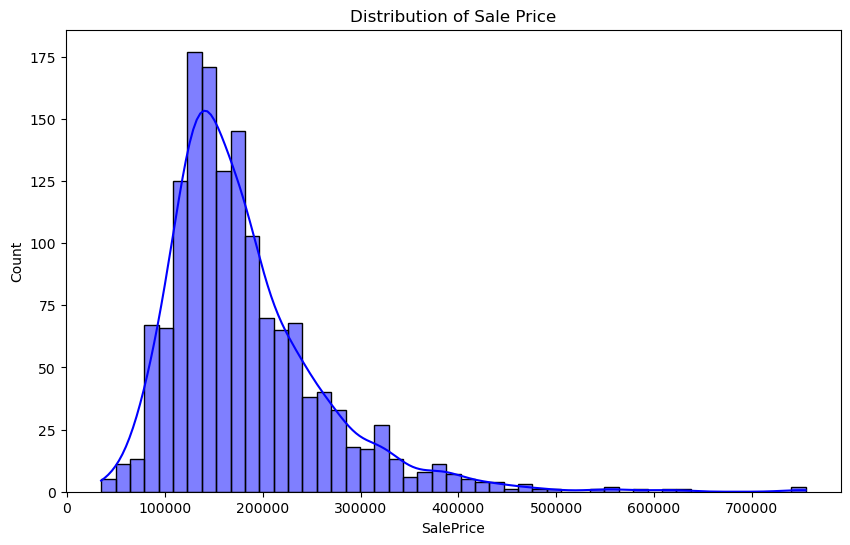

In [53]:
# visualize the distrubution of sales price
plt.figure(figsize = (10,6))
sns.histplot(train['SalePrice'], kde = True, color = 'blue')
plt.title('Distribution of Sale Price')
plt.show()

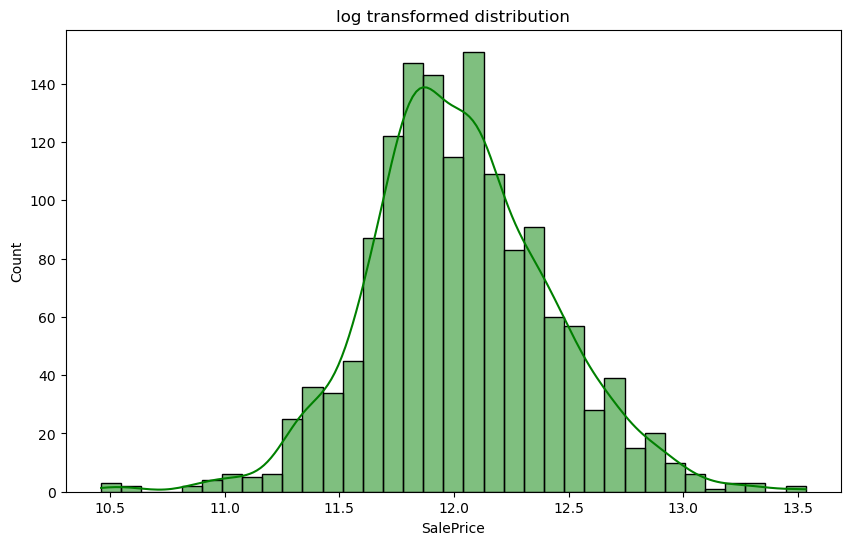

In [54]:
# checking log transformation as we find the above skewed a bit
plt.figure(figsize = (10,6))
sns.histplot(np.log1p(train['SalePrice']), kde = True, color = 'green')
plt.title('log transformed distribution')
plt.show()

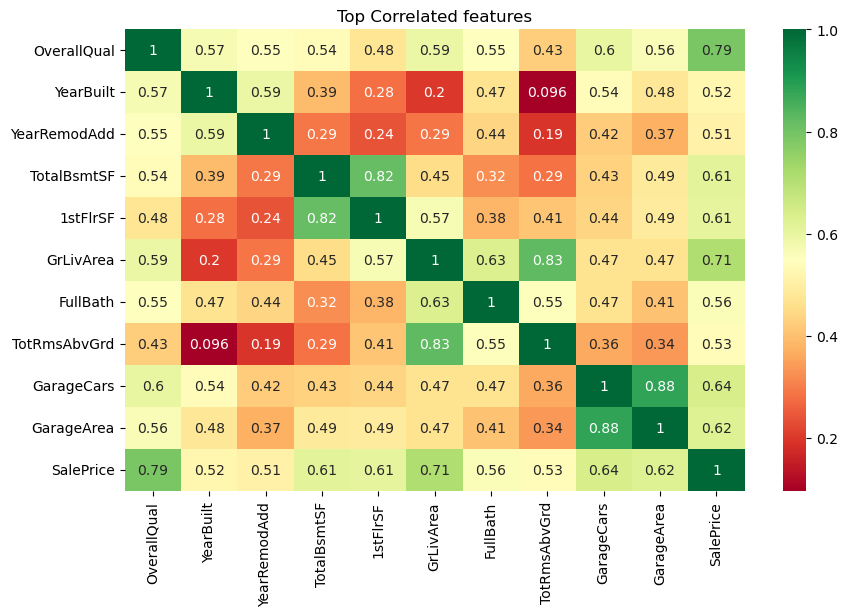

In [55]:
#Finding the high impact features
corrmat = train.corr(numeric_only = True)
corrmat
top_corr_features = corrmat.index[abs(corrmat['SalePrice'])>0.5]

#Lets visualize the top feature heatmap vs SalePrice
plt.figure(figsize=(10,6))
sns.heatmap(train[top_corr_features].corr(), annot = True, cmap ='RdYlGn')
plt.title('Top Correlated features')
plt.show()

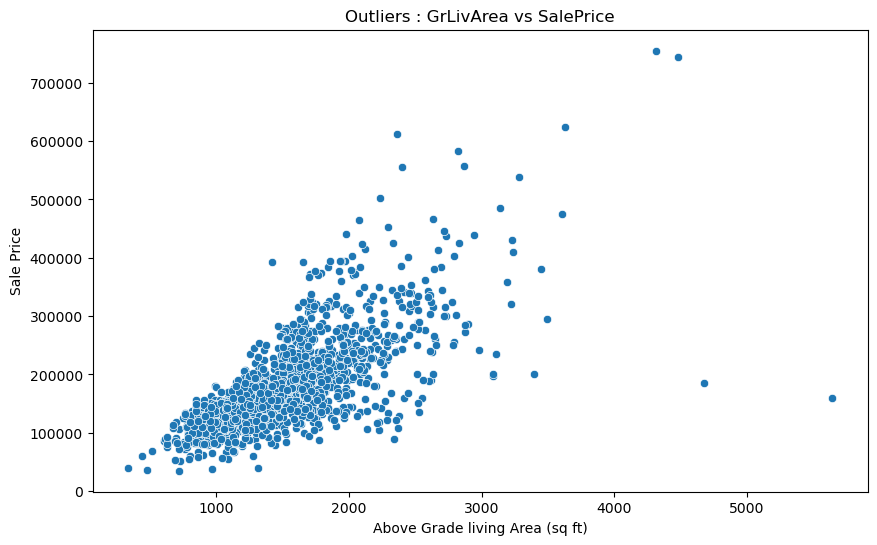

In [56]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])
plt.title('Outliers : GrLivArea vs SalePrice')
plt.xlabel('Above Grade living Area (sq ft)')
plt.ylabel('Sale Price')
plt.show()

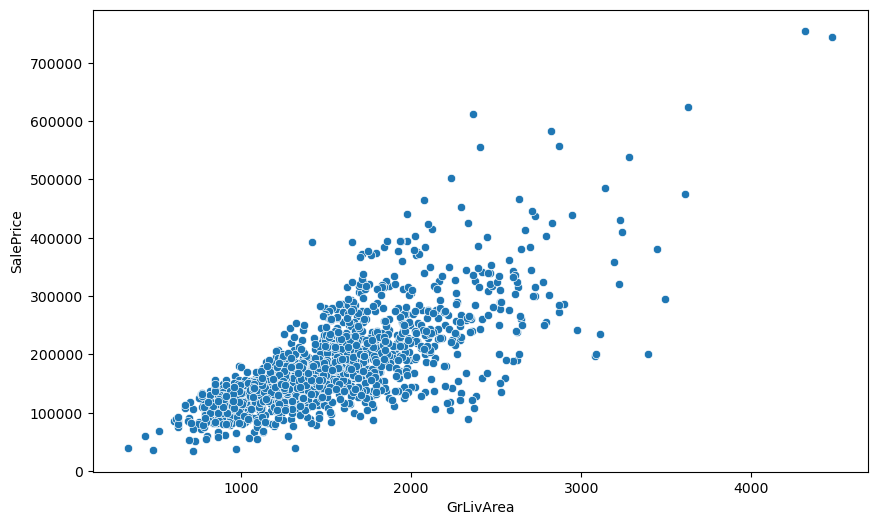

In [57]:
# Remove houses with area > 4000 sqft and Sale Price < 300000
train = train.drop(train[(train['GrLivArea']>4000) & (train['SalePrice']<300000)].index)
plt.figure(figsize=(10,6))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])
plt.show()

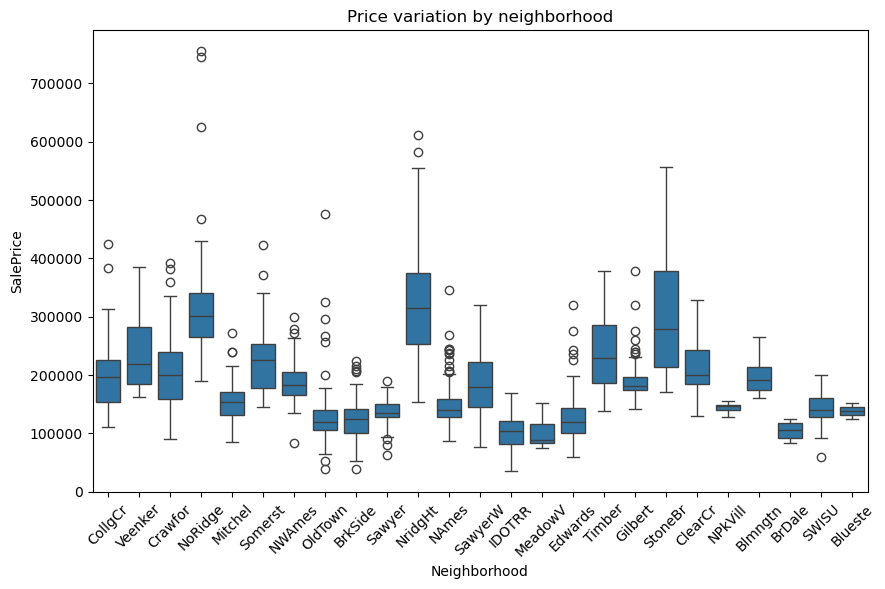

In [58]:
plt.figure(figsize=(10,6))
sns.boxplot( data = train, x='Neighborhood', y = 'SalePrice')
plt.xticks(rotation=45)
plt.title('Price variation by neighborhood')
plt.show()

In [59]:
temp_cat = train[cat_cols]

In [60]:
temp_num = train[num_cols]

In [61]:
train[cat_cols].isna().sum()

MSZoning            0
Street              0
Alley            1367
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinType2       38
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
KitchenQual         0
Functional          0
FireplaceQu       690
GarageType         81
GarageFinish       81
GarageQual         81
GarageCond         81
PavedDrive          0
PoolQC           1452
Fence            1177
MiscFeature      1404
SaleType            0
SaleCondition       0
dtype: int64

In [62]:
train[num_cols].isna().sum()

Id                 0
MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [63]:
# Imputation - Begin

empty_cat_cols_with_none = ['Alley', 'MasVnrType','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature']
for col in empty_cat_cols_with_none:
    train[col].fillna('None', inplace = True)

train['Electrical'].fillna(train['Electrical'].mode()[0], inplace = True)

In [64]:
train[cat_cols].isna().sum()

MSZoning         0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinType2     0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
KitchenQual      0
Functional       0
FireplaceQu      0
GarageType       0
GarageFinish     0
GarageQual       0
GarageCond       0
PavedDrive       0
PoolQC           0
Fence            0
MiscFeature      0
SaleType         0
SaleCondition    0
dtype: int64

In [65]:
# Imputation - contd...

train['LotFrontage'].fillna(train.groupby(['LotArea', 'Neighborhood'])['LotFrontage'].transform('median'), inplace = True)
train['MasVnrArea'].fillna(0, inplace = True)

In [66]:
def apply_feature_engg(data):
    # Mapping for Ordinals

    # 1. mapping for all quality related columns
    qualmap = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

    # List of ord features using 1st mapping
    ocols = ['FireplaceQu', 'GarageQual', 'GarageCond', 'BsmtCond', 'BsmtCond', 'ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual','PoolQC' ]

    for col in ocols:
        data[col] = data[col].map(qualmap)

    # 2. New map for exposure
    expmap = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
    data['BsmtExposure'] = data['BsmtExposure'].map(expmap)

    # 3. New map for finishing

    finmap = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
    data['BsmtFinType1'] = data['BsmtFinType1'].map(finmap)
    data['BsmtFinType2'] = data['BsmtFinType2'].map(finmap)


    data['TotalBuiltUp'] = data['TotalBsmtSF']+data['GrLivArea']
    data['TotalBath']=  data['BsmtFullBath']+data['FullBath']+ (0.5 * data['BsmtHalfBath']) + (0.5 * data['HalfBath'])
    data['TotalProchArea'] = data['OpenPorchSF']+data['EnclosedPorch']+ data['3SsnPorch']+data['ScreenPorch']
    data['HouseAge'] = data['YrSold'] - data['YearBuilt']
    data['RemodelAge'] = data['YrSold'] - data['YearRemodAdd']
    data['IsRemodeled'] = (data['YearBuilt'] != data['YearRemodAdd'] ).astype(int)
    data['HasBasement'] = data['TotalBsmtSF'].apply(lambda x: 1 if x>0 else 0)
    data['HasGarage'] = data['GarageArea'].apply(lambda x: 1 if x>0 else 0)
    data['Is NewHouse'] = (data['YearBuilt']==data['YrSold']).astype(int)

    return(data)

In [67]:
train_enriched = apply_feature_engg(train)

In [68]:
X = train_enriched.drop(['Id', 'SalePrice'], axis = 1)
y = np.log1p(train_enriched['SalePrice'])

num_features = X.select_dtypes(include = np.number).columns
cat_features = X.select_dtypes(exclude = np.number).columns

In [69]:
# Catagorical Transformer 
cat_transformer = Pipeline (steps =[
    ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'None')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
])

# Numerical Transformer
num_transformer = Pipeline (steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

# Preprocessing
preprocessor = ColumnTransformer (transformers = [
    ('cat_transform', cat_transformer, cat_features),
    ('num_transform', num_transformer, num_features)
])

In [70]:
lin_model = LinearRegression()

model_pipeline = Pipeline( steps = [
    ('preprocessor', preprocessor),
    ('model', lin_model)
])

In [71]:
train_X, test_X, train_y, test_y = train_test_split(X,y, test_size = 0.2, random_state = 42)

model_pipeline.fit(train_X, train_y)



,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_transform', ...), ('num_transform', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
test_X.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [73]:
train_preds = model_pipeline.predict(train_X)
test_preds = model_pipeline.predict(test_X)

In [74]:
def calculate_metrics(y, preds, label):
    true_val = np.expm1x(y)
    pred_val = np.expm1x(preds)

    mae = mean_absolute_error(true_val, pred_val)
    mse = mean_squared_error(true_val, pred_val)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_val, pred_val)
    sse = np.sum((true_val - pred_val)**2) # Manual SSE calculation
    
    print(f"--- Metrics for {label} ---")
    print(f"MAE:  ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"SSE:   {sse:,.2e}") # Using scientific notation for large numbers
    print(f"R^2:   {r2:.4f}\n")
    
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "SSE": sse}

In [75]:
train_results = calculate_metrics(train_y, train_preds, 'Training Set')
test_results = calculate_metrics(test_y, test_preds, 'Test Set')

--- Metrics for Training Set ---
MAE:  $10,918.96
RMSE: $16,335.31
SSE:   3.11e+11
R^2:   0.9590

--- Metrics for Test Set ---
MAE:  $15,359.63
RMSE: $22,159.07
SSE:   1.43e+11
R^2:   0.9111



In [76]:
act_test_data = pd.read_csv('test.csv')
act_test_enriched = apply_feature_engg(act_test_data)

In [77]:
train_enriched.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SalePrice,TotalBuiltUp,TotalBath,TotalProchArea,HouseAge,RemodelAge,IsRemodeled,HasBasement,HasGarage,Is NewHouse
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,208500,2566,3.5,61,5,5,0,1,1,0
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,181500,2524,2.5,0,31,31,0,1,1,0
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,223500,2706,3.5,42,7,6,1,1,1,0
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,140000,2473,2.0,307,91,36,1,1,1,0
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,250000,3343,3.5,84,8,8,0,1,1,0


In [78]:
act_test_enriched.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SaleCondition,TotalBuiltUp,TotalBath,TotalProchArea,HouseAge,RemodelAge,IsRemodeled,HasBasement,HasGarage,Is NewHouse
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,Normal,1778.0,1.0,120,49,49,0,1,1,0
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,Normal,2658.0,1.5,36,52,52,0,1,1,0
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,Normal,2557.0,2.5,34,13,12,1,1,1,0
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,Normal,2530.0,2.5,36,12,12,0,1,1,0
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,Normal,2560.0,2.0,226,18,18,0,1,1,0


In [79]:
act_test_preds = np.expm1x(model_pipeline.predict(act_test_enriched))


In [80]:
act_test_preds

array([119527.28991905, 168012.70666276, 180661.0987481 , ...,
       166570.12711169, 120008.57240824, 218232.77521639], shape=(1459,))

In [81]:
test_ids

0       1461
1       1462
2       1463
3       1464
4       1465
        ... 
1454    2915
1455    2916
1456    2917
1457    2918
1458    2919
Name: Id, Length: 1459, dtype: int64

In [82]:
import joblib
joblib.dump(model_pipeline, 'house_price_model.pkl')
app_x = train.drop(['Id', 'SalePrice'], axis = 1)

# 2. Calculate defaults for features ONLY
numeric_defaults = app_x.select_dtypes(include=['int64', 'float64']).median().to_dict()
categorical_defaults = app_x.select_dtypes(include=['object']).mode().iloc[0].to_dict()
defaults = {**numeric_defaults, **categorical_defaults}
joblib.dump(defaults, 'model_defaults.joblib')



['model_defaults.joblib']

In [83]:
defaults

{'MSSubClass': 50.0,
 'LotFrontage': 69.0,
 'LotArea': 9475.0,
 'OverallQual': 6.0,
 'OverallCond': 5.0,
 'YearBuilt': 1972.5,
 'YearRemodAdd': 1994.0,
 'MasVnrArea': 0.0,
 'ExterQual': 3.0,
 'ExterCond': 3.0,
 'BsmtCond': nan,
 'BsmtExposure': 1.0,
 'BsmtFinType1': 4.0,
 'BsmtFinSF1': 382.0,
 'BsmtFinType2': 1.0,
 'BsmtFinSF2': 0.0,
 'BsmtUnfSF': 477.5,
 'TotalBsmtSF': 991.0,
 'HeatingQC': 5.0,
 '1stFlrSF': 1086.0,
 '2ndFlrSF': 0.0,
 'LowQualFinSF': 0.0,
 'GrLivArea': 1461.5,
 'BsmtFullBath': 0.0,
 'BsmtHalfBath': 0.0,
 'FullBath': 2.0,
 'HalfBath': 0.0,
 'BedroomAbvGr': 3.0,
 'KitchenAbvGr': 1.0,
 'KitchenQual': 3.0,
 'TotRmsAbvGrd': 6.0,
 'Fireplaces': 1.0,
 'FireplaceQu': 2.0,
 'GarageYrBlt': 1980.0,
 'GarageCars': 2.0,
 'GarageArea': 479.5,
 'GarageQual': 3.0,
 'GarageCond': 3.0,
 'WoodDeckSF': 0.0,
 'OpenPorchSF': 24.5,
 'EnclosedPorch': 0.0,
 '3SsnPorch': 0.0,
 'ScreenPorch': 0.0,
 'PoolArea': 0.0,
 'PoolQC': 0.0,
 'MiscVal': 0.0,
 'MoSold': 6.0,
 'YrSold': 2008.0,
 'TotalBuiltU

In [84]:
numeric_defaults

{'MSSubClass': 50.0,
 'LotFrontage': 69.0,
 'LotArea': 9475.0,
 'OverallQual': 6.0,
 'OverallCond': 5.0,
 'YearBuilt': 1972.5,
 'YearRemodAdd': 1994.0,
 'MasVnrArea': 0.0,
 'ExterQual': 3.0,
 'ExterCond': 3.0,
 'BsmtCond': nan,
 'BsmtExposure': 1.0,
 'BsmtFinType1': 4.0,
 'BsmtFinSF1': 382.0,
 'BsmtFinType2': 1.0,
 'BsmtFinSF2': 0.0,
 'BsmtUnfSF': 477.5,
 'TotalBsmtSF': 991.0,
 'HeatingQC': 5.0,
 '1stFlrSF': 1086.0,
 '2ndFlrSF': 0.0,
 'LowQualFinSF': 0.0,
 'GrLivArea': 1461.5,
 'BsmtFullBath': 0.0,
 'BsmtHalfBath': 0.0,
 'FullBath': 2.0,
 'HalfBath': 0.0,
 'BedroomAbvGr': 3.0,
 'KitchenAbvGr': 1.0,
 'KitchenQual': 3.0,
 'TotRmsAbvGrd': 6.0,
 'Fireplaces': 1.0,
 'FireplaceQu': 2.0,
 'GarageYrBlt': 1980.0,
 'GarageCars': 2.0,
 'GarageArea': 479.5,
 'GarageQual': 3.0,
 'GarageCond': 3.0,
 'WoodDeckSF': 0.0,
 'OpenPorchSF': 24.5,
 'EnclosedPorch': 0.0,
 '3SsnPorch': 0.0,
 'ScreenPorch': 0.0,
 'PoolArea': 0.0,
 'PoolQC': 0.0,
 'MiscVal': 0.0,
 'MoSold': 6.0,
 'YrSold': 2008.0,
 'TotalBuiltU

In [85]:
categorical_defaults

{'MSZoning': 'RL',
 'Street': 'Pave',
 'Alley': 'None',
 'LotShape': 'Reg',
 'LandContour': 'Lvl',
 'Utilities': 'AllPub',
 'LotConfig': 'Inside',
 'LandSlope': 'Gtl',
 'Neighborhood': 'NAmes',
 'Condition1': 'Norm',
 'Condition2': 'Norm',
 'BldgType': '1Fam',
 'HouseStyle': '1Story',
 'RoofStyle': 'Gable',
 'RoofMatl': 'CompShg',
 'Exterior1st': 'VinylSd',
 'Exterior2nd': 'VinylSd',
 'MasVnrType': 'None',
 'Foundation': 'PConc',
 'BsmtQual': 'TA',
 'Heating': 'GasA',
 'CentralAir': 'Y',
 'Electrical': 'SBrkr',
 'Functional': 'Typ',
 'GarageType': 'Attchd',
 'GarageFinish': 'Unf',
 'PavedDrive': 'Y',
 'Fence': 'None',
 'MiscFeature': 'None',
 'SaleType': 'WD',
 'SaleCondition': 'Normal'}

In [86]:
'''submission = pd.DataFrame({
    'Id' : test_ids,
    'SalePrice' : act_test_preds
})
submission.to_csv('sub1_LinReg.csv', index = False)'''

"submission = pd.DataFrame({\n    'Id' : test_ids,\n    'SalePrice' : act_test_preds\n})\nsubmission.to_csv('sub1_LinReg.csv', index = False)"